# EDA on Retail Sales Data
## Oasis Infobyte — Data Analytics Internship
### Name: Priti Ranjit | Track: Data Analytics | Task: L1 Task 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load dataset (try different encodings if you get errors)
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (9994, 21)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Step 1: Initial Data Inspection

In [3]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

DATASET OVERVIEW

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segmen

## Step 2: Descriptive Statistics

In [4]:
print("Descriptive Statistics for Numerical Columns:")
df.describe()

Descriptive Statistics for Numerical Columns:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
print("Mean Sales:", df['Sales'].mean())
print("Median Sales:", df['Sales'].median())
print("Mode Sales:", df['Sales'].mode()[0])
print("Std Dev Sales:", df['Sales'].std())

print("\nMean Profit:", df['Profit'].mean())
print("Median Profit:", df['Profit'].median())

Mean Sales: 229.85800083049833
Median Sales: 54.489999999999995
Mode Sales: 12.96
Std Dev Sales: 623.2451005086807

Mean Profit: 28.65689630778467
Median Profit: 8.6665


## Step 3: Convert Date Column & Time Series Analysis

In [6]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year and Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

print("Date column converted successfully!")
df[['Order Date', 'Year', 'Month', 'Quarter']].head()

Date column converted successfully!


,Order Date,Year,Month,Quarter
0,2016-11-08,2016,11,4
1,2016-11-08,2016,11,4
2,2016-06-12,2016,6,2
3,2015-10-11,2015,10,4
4,2015-10-11,2015,10,4


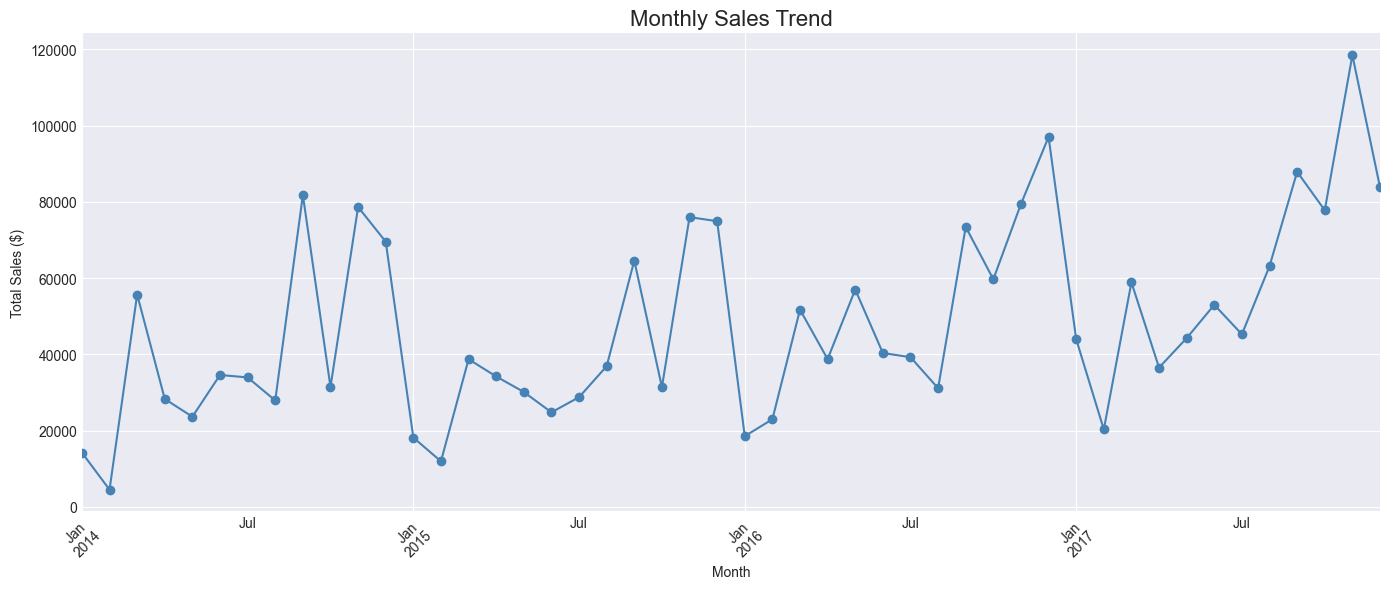

In [7]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png')
plt.show()

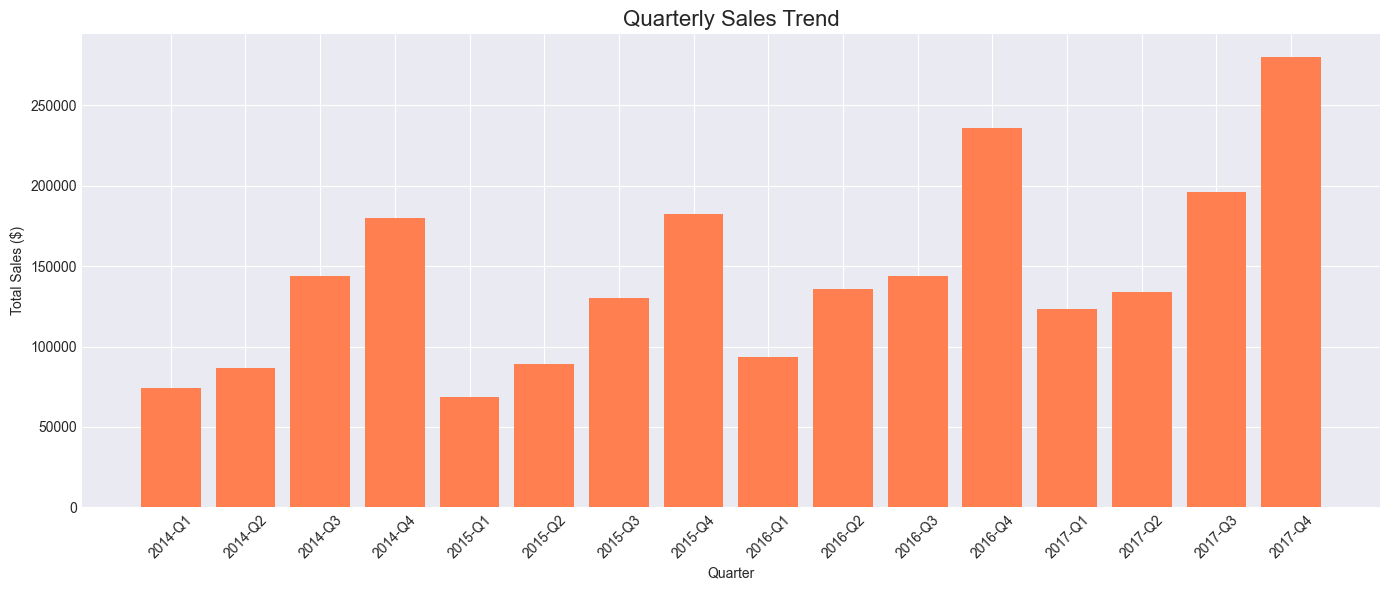

In [8]:
quarterly_sales = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
quarterly_sales['Period'] = quarterly_sales['Year'].astype(str) + '-Q' + quarterly_sales['Quarter'].astype(str)

plt.figure(figsize=(14, 6))
plt.bar(quarterly_sales['Period'], quarterly_sales['Sales'], color='coral')
plt.title('Quarterly Sales Trend', fontsize=16)
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('quarterly_sales.png')
plt.show()

## Step 4: Customer Demographics Analysis

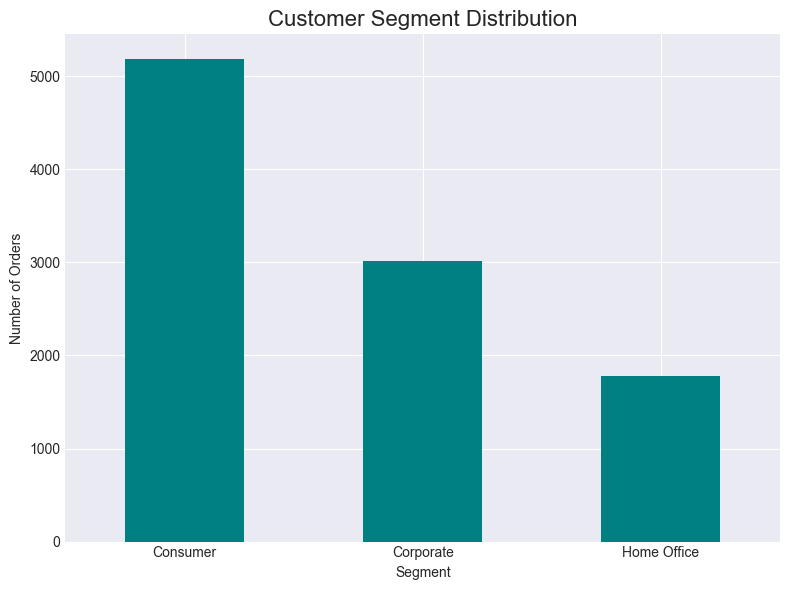

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(8, 6))
df['Segment'].value_counts().plot(kind='bar', color='teal')
plt.title('Customer Segment Distribution', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('segment_distribution.png')
plt.show()

print(df['Segment'].value_counts())

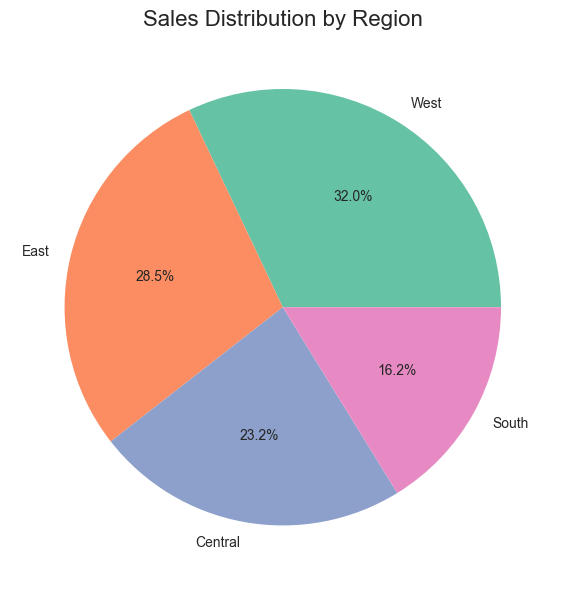

In [10]:
plt.figure(figsize=(8, 6))
df['Region'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                    colors=sns.color_palette('Set2'))
plt.title('Sales Distribution by Region', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.savefig('region_distribution.png')
plt.show()

## Step 5: Product Analysis

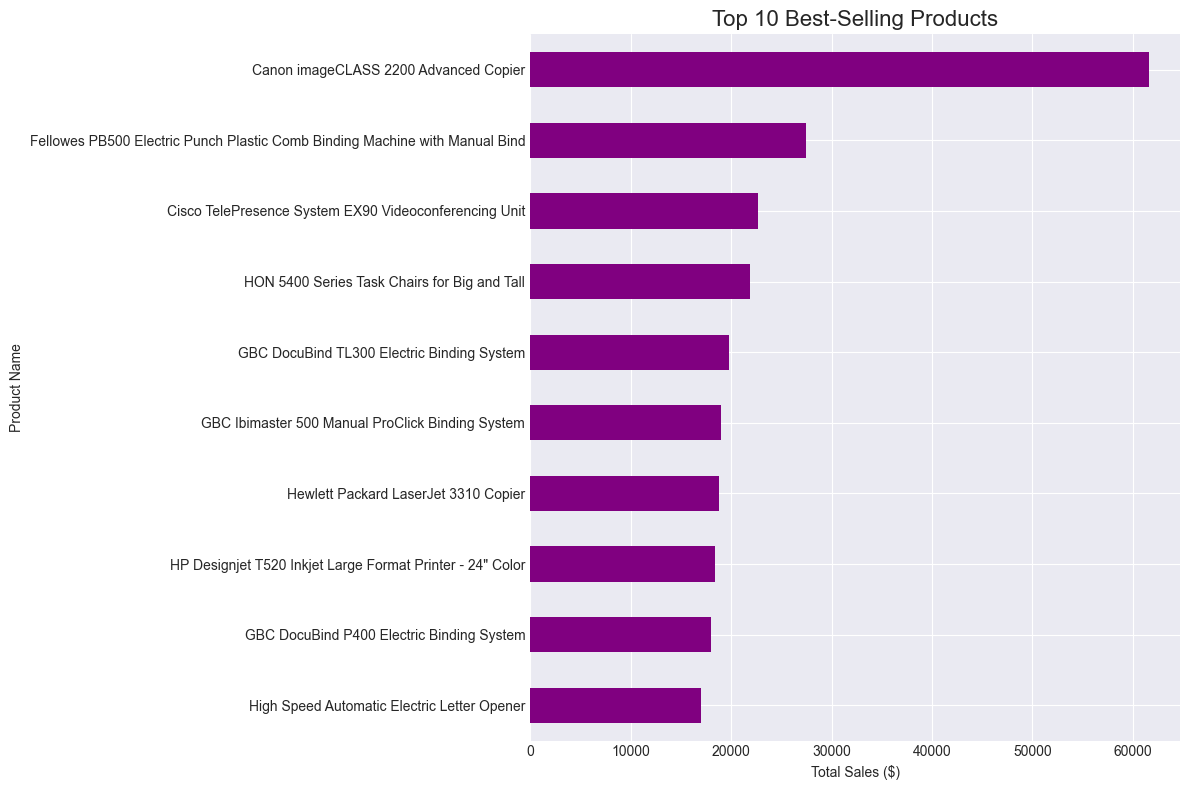

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [11]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
top_products.plot(kind='barh', color='purple')
plt.title('Top 10 Best-Selling Products', fontsize=16)
plt.xlabel('Total Sales ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

print(top_products)

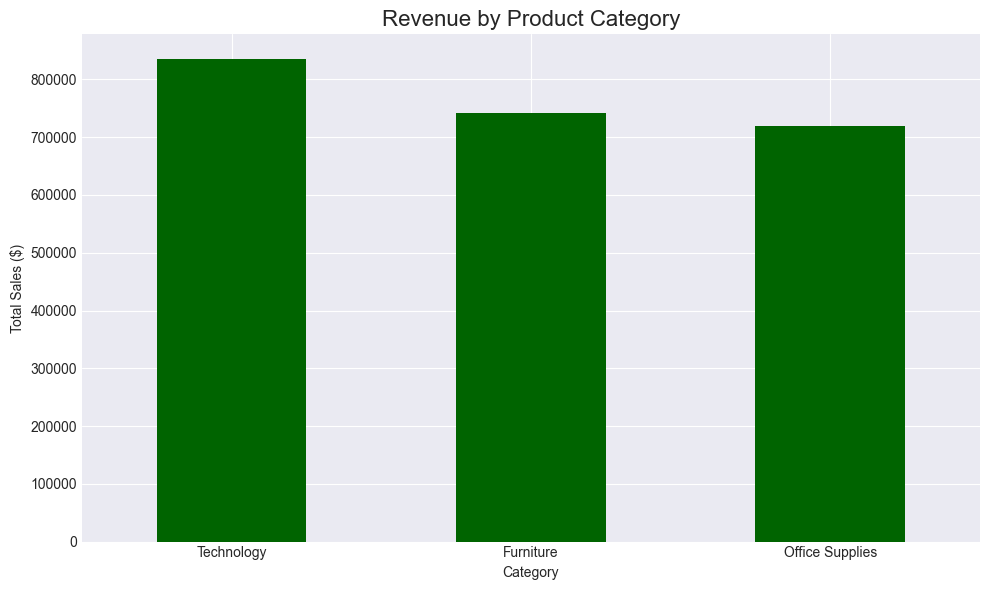

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [12]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar', color='darkgreen')
plt.title('Revenue by Product Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

print(category_sales)

## Step 6: Correlation Heatmap

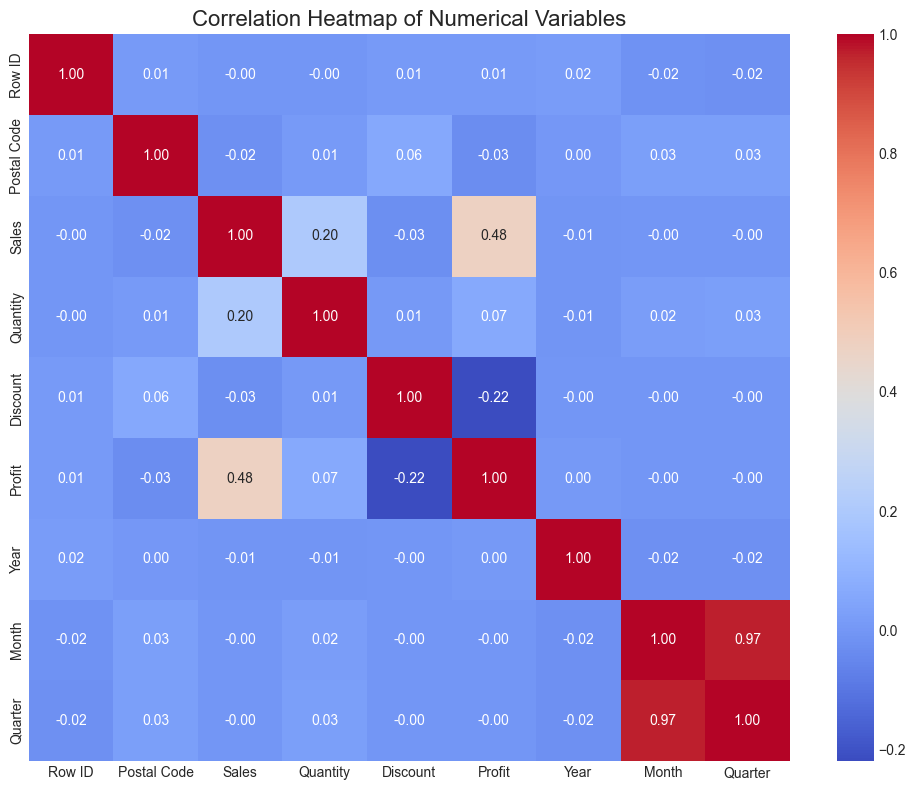

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

## Step 7: Additional Insight — Profit vs Discount

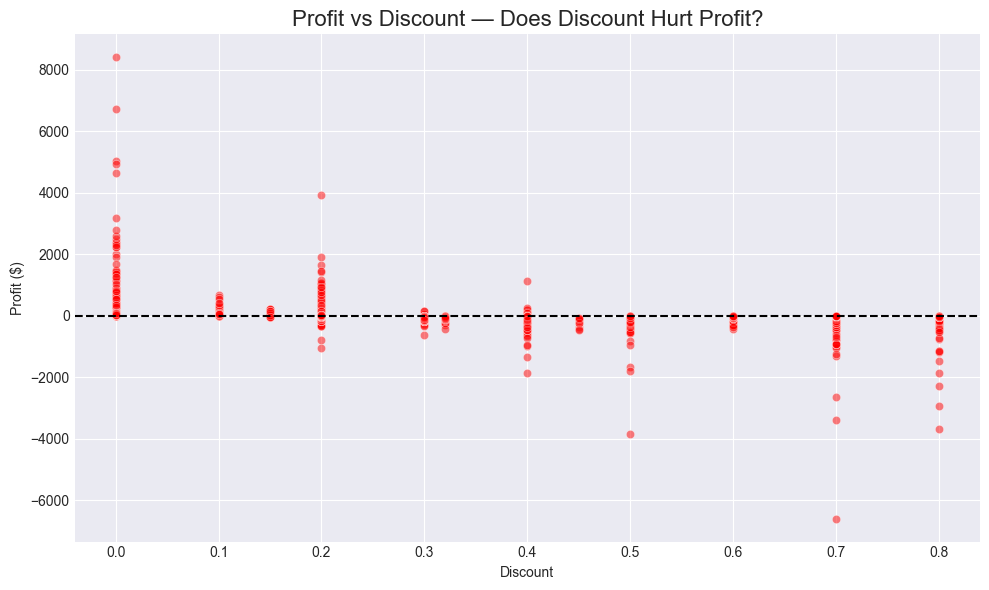

Correlation between Discount and Profit: -0.21948745637176834


In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='red')
plt.title('Profit vs Discount — Does Discount Hurt Profit?', fontsize=16)
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('profit_vs_discount.png')
plt.show()

print("Correlation between Discount and Profit:", 
      df['Discount'].corr(df['Profit']))


## Conclusion & Business Recommendations

### Key Findings:
1. Sales show clear monthly/quarterly seasonality with peaks in 
   certain months (likely Nov-Dec due to holiday shopping)
2. The Consumer segment generates the most orders
3. Technology and Office Supplies are the highest revenue categories
4. There is a negative correlation between Discount and Profit — 
   higher discounts often lead to lower or negative profits

### Business Recommendations:
1. **Reduce high discounts** on products where they clearly hurt profit margins
2. **Focus marketing budget** on top-performing regions and categories
3. **Stock up inventory** before peak sales months identified in the 
   time series analysis